In [1]:
import sys                                                                                                                                                   
sys.path.append('..')                                                            
import torchvision
import torchvision.transforms as transforms
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from src.pipeline import run_pipeline
from src.evaluation import random_baseline
from src.representations import load_encoder, extract_embeddings

In [2]:
import pickle, os

# Set to True to load saved results (skips all experiments)
# Set to False to run experiments from scratch
LOAD_SAVED = os.path.exists('./experiment_results.pkl')

if LOAD_SAVED:
    with open('./experiment_results.pkl', 'rb') as f:
        saved = pickle.load(f)
    baseline_result = saved['baseline']
    random_results = saved['random']
    hybrid_results = saved['hybrid']
    pca_results = saved['pca']
    umap_results = saved['umap']
    overcluster_results = saved['overcluster']
    print("Loaded saved results from experiment_results.pkl")
else:
    print("No saved results found — will run experiments from scratch")

Loaded saved results from experiment_results.pkl


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=256, shuffle=False, num_workers=2)
testloader = DataLoader(testset, batch_size=256, shuffle=False, num_workers=2)

encoder = load_encoder('./simclr_encoder_200ep.pth')
embeddings, labels = extract_embeddings(encoder=encoder, dataloader=trainloader)
test_embeddings, test_labels = extract_embeddings(encoder=encoder, dataloader=testloader)

### Baseline

In [4]:
baseline_config = {                                                           
    'preprocess': 'none',                                                     
    'cluster': 'standard',                                                    
    'selection': 'max_typicality',                                         
    'budget': 10,
}
baseline_result = run_pipeline(embeddings, labels, test_embeddings,
test_labels, baseline_config)

random_results = random_baseline(embeddings, labels, test_embeddings, test_labels, budget=10, n_seeds=30)

### Hybrid Selection Alpha Sweep

In [5]:
alpha_values = [0.0, 0.1, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]                                          
hybrid_results = {}                                                           
                                    
for alpha in alpha_values:                                                    
    config = {                                                              
        'preprocess': 'none',                                                 
        'cluster': 'standard',                                                
        'selection': 'select_hybrid',
        'budget': 10,
        'alpha': alpha,
    }
    hybrid_results[alpha] = run_pipeline(embeddings, labels, test_embeddings, test_labels, config)

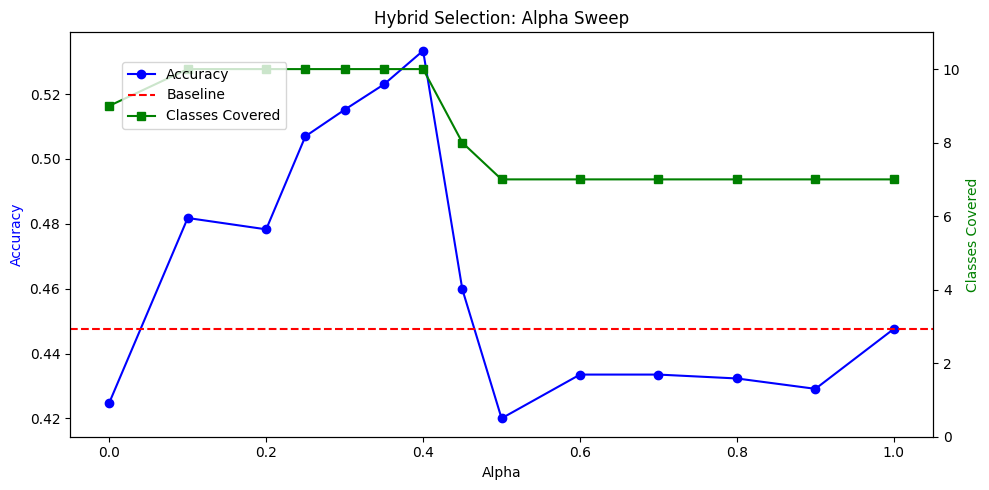

In [6]:
# Hybrid sweep visualization
fig, ax1 = plt.subplots(figsize=(10, 5))
alphas = list(hybrid_results.keys())
accs = [hybrid_results[a]['accuracy'] for a in alphas]
classes = [hybrid_results[a]['n_classes_covered'] for a in alphas]

ax1.plot(alphas, accs, 'b-o', label='Accuracy')
ax1.set_xlabel('Alpha')
ax1.set_ylabel('Accuracy', color='b')
ax1.axhline(y=baseline_result['accuracy'], color='r', linestyle='--', label='Baseline')

ax2 = ax1.twinx()
ax2.plot(alphas, classes, 'g-s', label='Classes Covered')
ax2.set_ylabel('Classes Covered', color='g')
ax2.set_ylim(0, 11)

fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.title('Hybrid Selection: Alpha Sweep')
plt.tight_layout()
plt.show()

### PCA & UMAP

**PCA Dimensionality Sweep**

In [7]:
pca_dims = [10, 20, 30, 50, 100, 256]               
pca_results = {}                                                              
                            
for n in pca_dims:                                                            
    config = {                                                              
        'preprocess': 'pca',                                                  
        'n_components': n,                                                    
        'cluster': 'standard',
        'selection': 'select_hybrid',
        'budget': 10,
        'alpha': 0.55,
    }
    pca_results[n] = run_pipeline(embeddings, labels, test_embeddings, test_labels, config)

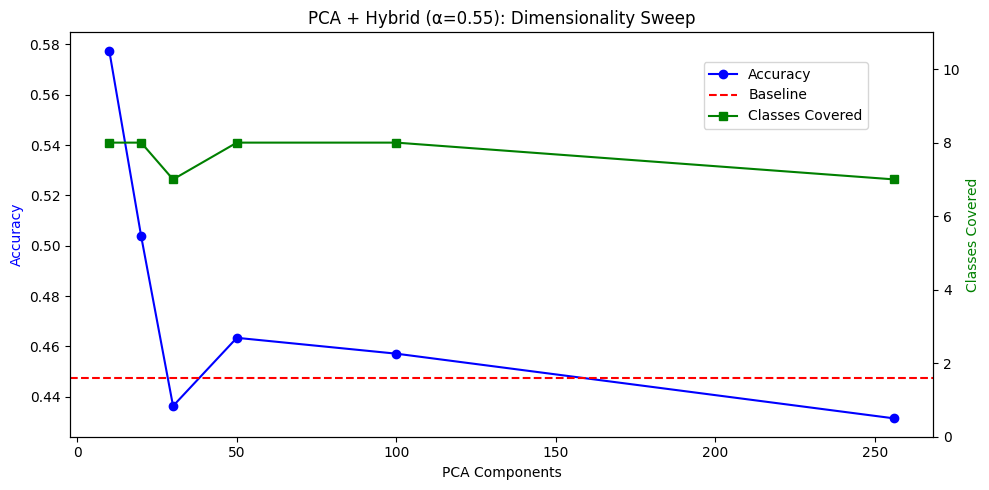

In [8]:
# PCA sweep visualization
fig, ax1 = plt.subplots(figsize=(10, 5))
dims = list(pca_results.keys())
accs = [pca_results[d]['accuracy'] for d in dims]
classes = [pca_results[d]['n_classes_covered'] for d in dims]

ax1.plot(dims, accs, 'b-o', label='Accuracy')
ax1.set_xlabel('PCA Components')
ax1.set_ylabel('Accuracy', color='b')
ax1.axhline(y=baseline_result['accuracy'], color='r', linestyle='--', label='Baseline')

ax2 = ax1.twinx()
ax2.plot(dims, classes, 'g-s', label='Classes Covered')
ax2.set_ylabel('Classes Covered', color='g')
ax2.set_ylim(0, 11)

fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.title('PCA + Hybrid (α=0.55): Dimensionality Sweep')
plt.tight_layout()
plt.show()

**UMAP Full Grid**

In [9]:
umap_dims = [5, 10, 20]
umap_alphas = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
umap_results = {}

for n in umap_dims:
    for alpha in umap_alphas:
        config = {
            'preprocess': 'umap',
            'n_components': n,
            'cluster': 'standard',
            'selection': 'select_hybrid',
            'budget': 10,
            'alpha': alpha,
        }
        umap_results[(n, alpha)] = run_pipeline(embeddings, labels, 
                                                test_embeddings, test_labels, config)
        print(f"UMAP n={n}, alpha={alpha}: {umap_results[(n, alpha)]['accuracy']:.4f}")

/mnt/data/conda/envs/ml-cw2/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP n=5, alpha=0.0: 0.6179


/mnt/data/conda/envs/ml-cw2/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP n=5, alpha=0.2: 0.6949


/mnt/data/conda/envs/ml-cw2/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


...

UMAP n=20, alpha=0.6: 0.6456


/mnt/data/conda/envs/ml-cw2/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP n=20, alpha=0.8: 0.6509


/mnt/data/conda/envs/ml-cw2/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP n=20, alpha=1.0: 0.6379


**Visualization**

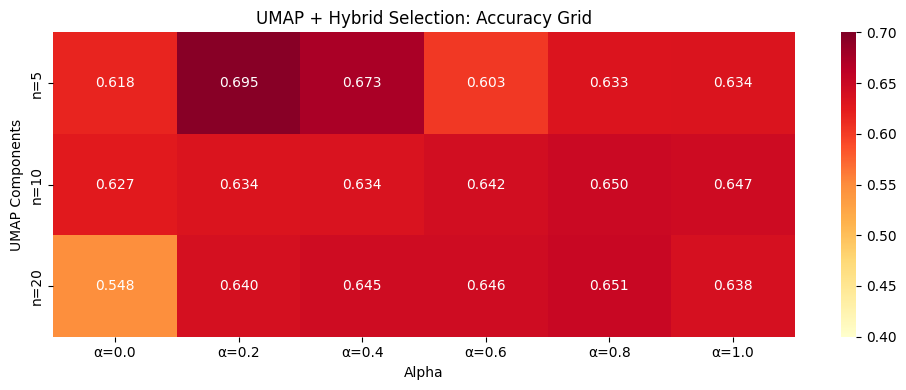

In [10]:

heatmap_data = pd.DataFrame([[umap_results[(n, a)]['accuracy'] for a in umap_alphas] for n in
umap_dims],
    index=[f'n={n}' for n in umap_dims],
    columns=[f'α={a}' for a in umap_alphas]
)

plt.figure(figsize=(10, 4))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd', vmin=0.4,
vmax=0.7)
plt.title('UMAP + Hybrid Selection: Accuracy Grid')
plt.ylabel('UMAP Components')
plt.xlabel('Alpha')
plt.tight_layout()
plt.show()

### Over-clustering

In [11]:
cluster_mults = [2, 3, 5, 10]                    
overcluster_results = {}                            
                                                                            
for preprocess, n_comp, alpha in [('pca', 10, 0.55), ('umap', 5, 0.2)]:
    for mult in cluster_mults:                                                
        config = {                                                          
            'preprocess': preprocess,                                         
            'n_components': n_comp,                                           
            'cluster': 'overclustering',
            'selection': 'select_hybrid',
            'budget': 10,
            'alpha': alpha,
            'cluster_mult': mult,
        }
        overcluster_results[(preprocess, mult)] = run_pipeline(embeddings, labels, test_embeddings, test_labels, config)

/mnt/data/conda/envs/ml-cw2/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/mnt/data/conda/envs/ml-cw2/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/mnt/data/conda/envs/ml-cw2/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/mnt/data/conda/envs/ml-cw2/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


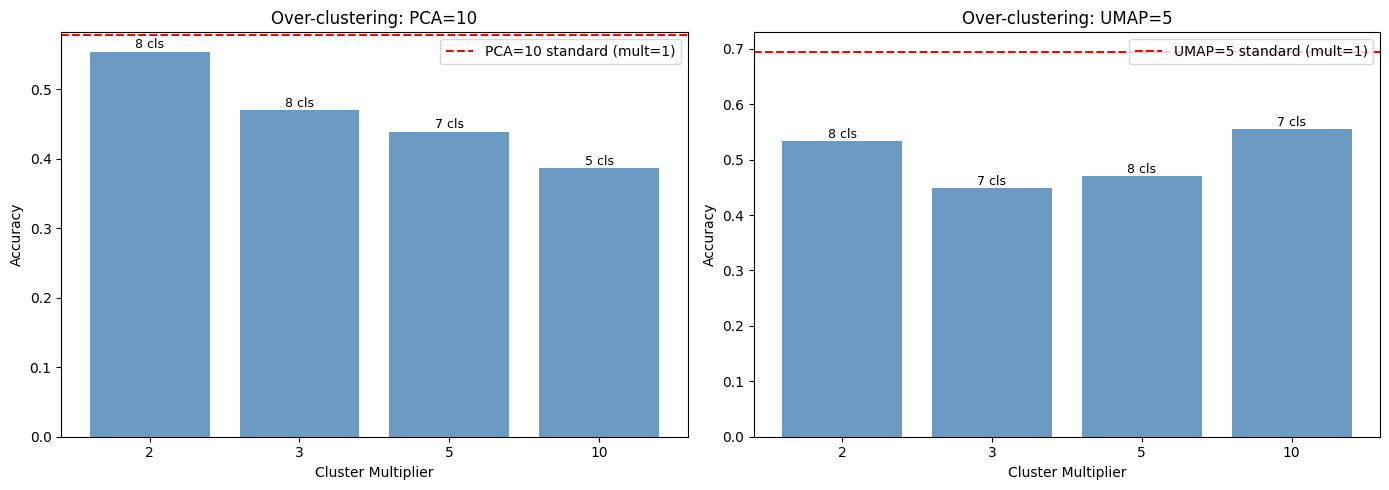

In [12]:
# Over-clustering visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (preprocess, label, best_acc) in enumerate([('pca', 'PCA=10', pca_results[10]['accuracy']), 
                                                       ('umap', 'UMAP=5', umap_results[(5, 0.2)]['accuracy'])]):
    ax = axes[idx]
    mults = cluster_mults
    accs = [overcluster_results[(preprocess, m)]['accuracy'] for m in mults]
    classes = [overcluster_results[(preprocess, m)]['n_classes_covered'] for m in mults]
    
    bars = ax.bar([str(m) for m in mults], accs, color='steelblue', alpha=0.8)
    ax.axhline(y=best_acc, color='r', linestyle='--', label=f'{label} standard (mult=1)')
    ax.set_xlabel('Cluster Multiplier')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Over-clustering: {label}')
    ax.legend()
    
    # Annotate classes covered
    for bar, c in zip(bars, classes):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
                f'{c} cls', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [13]:
# Save all results to disk
import pickle
with open('./experiment_results.pkl', 'wb') as f:
    pickle.dump({
        'baseline': baseline_result,
        'random': random_results,
        'hybrid': hybrid_results,
        'pca': pca_results,
        'umap': umap_results,
        'overcluster': overcluster_results,
    }, f)
print("Results saved to experiment_results.pkl")

Results saved to experiment_results.pkl


## Summary Table

In [14]:
summary = pd.DataFrame([
      {'Method': 'Random', 'Accuracy': random_results['mean'], 'Classes': '-',
  'TV': '-'},
      {'Method': 'Baseline (TypiClust)', 'Accuracy':
  baseline_result['accuracy'], 'Classes': baseline_result['n_classes_covered'],
  'TV': baseline_result['tv_distance']},
      {'Method': 'Hybrid (α=0.4)', 'Accuracy': hybrid_results[0.4]['accuracy'],
  'Classes': hybrid_results[0.4]['n_classes_covered'], 'TV':
  hybrid_results[0.4]['tv_distance']},
      {'Method': 'PCA=10 + Hybrid', 'Accuracy': pca_results[10]['accuracy'],
  'Classes': pca_results[10]['n_classes_covered'], 'TV':
  pca_results[10]['tv_distance']},
      {'Method': 'UMAP=5 + Hybrid', 'Accuracy': umap_results[(5,
  0.2)]['accuracy'], 'Classes': umap_results[(5, 0.2)]['n_classes_covered'],
  'TV': umap_results[(5, 0.2)]['tv_distance']},
  ])
print(summary.to_string(index=False))


              Method  Accuracy Classes   TV
              Random   0.36916       -    -
Baseline (TypiClust)   0.44760       7  0.3
      Hybrid (α=0.4)   0.53340      10  0.0
     PCA=10 + Hybrid   0.57750       8  0.2
     UMAP=5 + Hybrid   0.69490      10  0.0


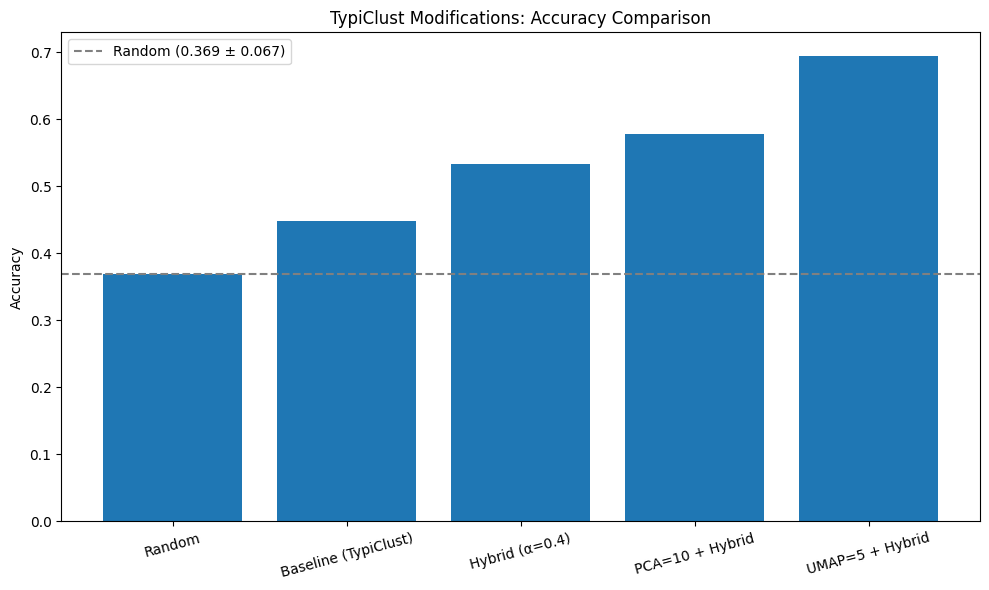

In [15]:
plt.figure(figsize=(10, 6))
plt.bar(summary['Method'], summary['Accuracy'].astype(float))
plt.axhline(y=random_results['mean'], color='gray', linestyle='--',
label=f"Random ({random_results['mean']:.3f} ± {random_results['std']:.3f})")
plt.ylabel('Accuracy')
plt.title('TypiClust Modifications: Accuracy Comparison')
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.show()

## Statistical Analysis

In [16]:
from scipy import stats
import numpy as np

random_accs = np.array(random_results['all'])

# Summary statistics for random baseline
print("=== Random Baseline (30 seeds) ===")
print(f"Mean: {random_accs.mean():.4f}")
print(f"Std:  {random_accs.std():.4f}")
print(f"95% CI: [{random_accs.mean() - 1.96*random_accs.std()/np.sqrt(len(random_accs)):.4f}, "
      f"{random_accs.mean() + 1.96*random_accs.std()/np.sqrt(len(random_accs)):.4f}]")
print()

# One-sample t-tests: is each method significantly better than random mean?
methods = {
    'Baseline (TypiClust)': baseline_result['accuracy'],
    'Hybrid (α=0.4)': hybrid_results[0.4]['accuracy'],
    'PCA=10 + Hybrid (α=0.55)': pca_results[10]['accuracy'],
    'UMAP=5 + Hybrid (α=0.2)': umap_results[(5, 0.2)]['accuracy'],
}

print("=== One-Sample t-test: Method accuracy vs Random distribution ===")
for name, acc in methods.items():
    t_stat, p_value = stats.ttest_1samp(random_accs, acc)
    cohens_d = (acc - random_accs.mean()) / random_accs.std()
    sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
    print(f"{name:>30s}: acc={acc:.4f}, t={t_stat:>7.2f}, p={p_value:.4e}, Cohen's d={cohens_d:.2f} {sig}")

=== Random Baseline (30 seeds) ===
Mean: 0.3692
Std:  0.0675
95% CI: [0.3450, 0.3933]

=== One-Sample t-test: Method accuracy vs Random distribution ===
          Baseline (TypiClust): acc=0.4476, t=  -6.26, p=7.8313e-07, Cohen's d=1.16 ***
                Hybrid (α=0.4): acc=0.5334, t= -13.11, p=1.0319e-13, Cohen's d=2.43 ***
      PCA=10 + Hybrid (α=0.55): acc=0.5775, t= -16.63, p=2.2954e-16, Cohen's d=3.09 ***
       UMAP=5 + Hybrid (α=0.2): acc=0.6949, t= -25.99, p=1.2133e-21, Cohen's d=4.83 ***


## Multi-Seed Evaluation
Run each method across 10 K-Means seeds to get mean/std for robust reporting.

In [17]:
import numpy as np
from scipy import stats

seeds = list(range(10, 20))  # 10 different seeds

# Define the 4 method configs (without random_state — we'll set it per seed)
method_configs = {
    'Baseline (TypiClust)': {
        'preprocess': 'none',
        'cluster': 'standard',
        'selection': 'max_typicality',
        'budget': 10,
    },
    'Hybrid (α=0.4)': {
        'preprocess': 'none',
        'cluster': 'standard',
        'selection': 'select_hybrid',
        'budget': 10,
        'alpha': 0.4,
    },
    'PCA-10 + Hybrid (α=0.55)': {
        'preprocess': 'pca',
        'n_components': 10,
        'cluster': 'standard',
        'selection': 'select_hybrid',
        'budget': 10,
        'alpha': 0.55,
    },
    'UMAP-5 + Hybrid (α=0.2)': {
        'preprocess': 'umap',
        'n_components': 5,
        'cluster': 'standard',
        'selection': 'select_hybrid',
        'budget': 10,
        'alpha': 0.2,
    },
}

multi_seed_results = {}

for name, base_config in method_configs.items():
    accs = []
    classes_list = []
    for seed in seeds:
        config = base_config.copy()
        config['random_state'] = seed  # This now controls both K-Means and UMAP seeds
        result = run_pipeline(embeddings, labels, test_embeddings, test_labels, config)
        accs.append(result['accuracy'])
        classes_list.append(result['n_classes_covered'])
    
    accs = np.array(accs)
    multi_seed_results[name] = {
        'accs': accs,
        'mean': accs.mean(),
        'std': accs.std(),
        'classes_mean': np.mean(classes_list),
        'classes_list': classes_list,
    }
    print(f"{name:>35s}: {accs.mean():.4f} ± {accs.std():.4f}  (classes: {np.mean(classes_list):.1f})")

               Baseline (TypiClust): 0.4442 ± 0.0042  (classes: 7.0)
                     Hybrid (α=0.4): 0.5334 ± 0.0000  (classes: 10.0)
           PCA-10 + Hybrid (α=0.55): 0.5775 ± 0.0000  (classes: 8.0)


/mnt/data/conda/envs/ml-cw2/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/mnt/data/conda/envs/ml-cw2/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/mnt/data/conda/envs/ml-cw2/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/mnt/data/conda/envs/ml-cw2/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/mnt/data/conda/envs/ml-cw2/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/mnt/data/conda/envs/ml-cw2/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarn

            UMAP-5 + Hybrid (α=0.2): 0.6578 ± 0.0171  (classes: 9.6)


In [18]:
# Two-sample t-tests: each method (10 seeds) vs random baseline (30 seeds)
random_accs = np.array(random_results['all'])

print("=== Two-Sample t-test: Method (10 seeds) vs Random (30 seeds) ===\n")
for name, data in multi_seed_results.items():
    method_accs = data['accs']
    t_stat, p_value = stats.ttest_ind(method_accs, random_accs)
    # Cohen's d for independent samples
    pooled_std = np.sqrt((method_accs.std()**2 + random_accs.std()**2) / 2)
    cohens_d = (method_accs.mean() - random_accs.mean()) / pooled_std
    ci_low = method_accs.mean() - 1.96 * method_accs.std() / np.sqrt(len(method_accs))
    ci_high = method_accs.mean() + 1.96 * method_accs.std() / np.sqrt(len(method_accs))
    sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
    print(f"{name:>35s}:")
    print(f"  Mean={data['mean']:.4f} ± {data['std']:.4f}, 95% CI: [{ci_low:.4f}, {ci_high:.4f}]")
    print(f"  t={t_stat:.2f}, p={p_value:.4e}, Cohen's d={cohens_d:.2f} {sig}")
    print()

# Bonferroni correction note
print("Bonferroni-adjusted significance threshold: α = 0.05/4 = 0.0125")

=== Two-Sample t-test: Method (10 seeds) vs Random (30 seeds) ===

               Baseline (TypiClust):
  Mean=0.4442 ± 0.0042, 95% CI: [0.4415, 0.4468]
  t=3.42, p=1.4953e-03, Cohen's d=1.57 **

                     Hybrid (α=0.4):
  Mean=0.5334 ± 0.0000, 95% CI: [0.5334, 0.5334]
  t=7.50, p=5.2064e-09, Cohen's d=3.44 ***

           PCA-10 + Hybrid (α=0.55):
  Mean=0.5775 ± 0.0000, 95% CI: [0.5775, 0.5775]
  t=9.52, p=1.3310e-11, Cohen's d=4.37 ***

            UMAP-5 + Hybrid (α=0.2):
  Mean=0.6578 ± 0.0171, 95% CI: [0.6472, 0.6685]
  t=13.05, p=1.3013e-15, Cohen's d=5.86 ***

Bonferroni-adjusted significance threshold: α = 0.05/4 = 0.0125


/mnt/data/conda/envs/ml-cw2/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [19]:
# Save multi-seed results to the pickle
import pickle
with open('./experiment_results.pkl', 'rb') as f:
    saved = pickle.load(f)

# Convert numpy arrays to lists for pickle compatibility
saved['multi_seed'] = {
    name: {
        'accs': data['accs'].tolist(),
        'mean': data['mean'],
        'std': data['std'],
        'classes_mean': data['classes_mean'],
        'classes_list': data['classes_list'],
    }
    for name, data in multi_seed_results.items()
}

with open('./experiment_results.pkl', 'wb') as f:
    pickle.dump(saved, f)
print("Multi-seed results saved to experiment_results.pkl")

Multi-seed results saved to experiment_results.pkl
